# Phonons: the second derivative of the energy, at $\Gamma$ and beyond

A phonon frequency is an eigenvalue of the force constant matrix -- the second derivative of
the total energy with respect to the atomic positions -- divided by the masses:

$$ C_{i j} = \frac{\partial^2 E}{\partial u_i\,\partial u_j},
\qquad
\det\!\left[\frac{C_{ij}}{\sqrt{M_i M_j}} - \omega^2\right] = 0 $$

Two things contribute. The atoms move in a frozen electronic cloud, and the electrons then
follow them, which is a linear response problem and the reason a phonon costs more than a
force:

$$ \frac{\partial^2 E}{\partial u_i\,\partial u_j}
   = \underbrace{\partial_i \partial_j E}_{\text{atoms move}}
   + \underbrace{(\partial_\psi \partial_j E)\cdot \frac{d\psi}{du_i}}_{\text{electrons follow}} $$

Both come out of differentiating the force of notebook 09 *once more*, along a direction that
carries the positions, the states and the density together, so nothing is derived by hand and
no second-order wavefunction is needed.

| silicon at $\Gamma$ | defumat | `ph.x` |
|---|---|---|
| optical mode ($\Gamma_{25'}$, triply degenerate) | **510.102 cm⁻¹** | 510.152 |
| acoustic modes (zero by translation invariance) | 4.09 | 2.05 |
| the same cell, **ultrasoft** | **513.295** | 513.275 |
| the same cell, **PAW** | **513.378** | 513.404 |
| two-atom aluminium, a **metal** | **311.0335 cm⁻¹** | 311.035 |
| silicon at $L$, worst of six branches | **0.054 cm⁻¹** from `ph.x` | |
| silicon at $X$, worst of six branches | **0.038 cm⁻¹** from `ph.x` | |

The acoustic residue is a *diagnostic* rather than an answer, and the section below is about
what it measures.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator

CASES, PSEUDO = Path("../tests/data/qe"), Path("../tests/data/pseudo")

silicon = Calculator.from_file(CASES / "si-epsilon.in", pseudo_dir=PSEUDO, announce=False)
phonons = silicon.get_phonons()
print("silicon at Gamma [cm^-1]:  %s"
      % np.array2string(phonons.frequencies, precision=3))
print("ph.x:                      2.045258 x3,   510.151844 x3")

silicon at Gamma [cm^-1]:  [  4.088   4.088   4.088 510.102 510.102 510.102]
ph.x:                      2.045258 x3,   510.151844 x3


One call, and inside it a bare perturbation per mode -- six here -- a self-consistent
response solved for all of them together, and then the second derivative itself.

The force constants come out in Ry/bohr². Two atoms, so a $6\times6$ matrix, and because the
two silicons are related by symmetry there are only two independent numbers in it:

In [2]:
on_site = phonons.matrix[0, :, 0, :]
between = phonons.matrix[0, :, 1, :]
print("D[Si_1, Si_1] =\n", np.round(on_site, 9))
print("D[Si_1, Si_2] =\n", np.round(between, 9))
print("\nisotropic on-site block to      %.1e"
      % np.abs(on_site - np.eye(3) * on_site[0, 0]).max())
print("asymmetry, max |D - D^T|        %.1e" % phonons.asymmetry)
print("acoustic sum rule, D_00 + D_01  %.3e" % (on_site[0, 0] + between[0, 0]))

D[Si_1, Si_1] =
 [[0.276582 0.       0.      ]
 [0.       0.276582 0.      ]
 [0.       0.       0.276582]]
D[Si_1, Si_2] =
 [[-0.27654648 -0.         -0.        ]
 [-0.         -0.27654648 -0.        ]
 [-0.          0.         -0.27654648]]

isotropic on-site block to      6.9e-17
asymmetry, max |D - D^T|        1.7e-16
acoustic sum rule, D_00 + D_01  3.552e-05


## What a phonon actually is

The optical mode is the two sublattices moving against each other, and what makes it cost
energy is the charge that has to rearrange when they do. The induced density $d\rho/du$ *is*
that charge.

**Left**, the charge induced by displacing one silicon along $x$, summed down one crystal
axis so the whole cell is in view. It is antisymmetric about the displacement, as it must be
-- charge leaves one side of the atom and arrives on the other -- and the second sublattice,
which has not moved, responds too. Paying for that rearrangement is most of what makes the
optical mode cost 510 cm⁻¹ rather than nothing.

**Right**, the check that costs nothing and tests everything. Displace *every* atom by the
same vector and the crystal has merely been translated, so the response has to be the
ground state's own density gradient, $\sum_a d\rho_{a,x} = -\partial\rho/\partial x$. The
right-hand side is obtained by differentiating $\rho$ in reciprocal space and shares no
machinery with the left.

max relative difference over the whole grid   6.5e-05


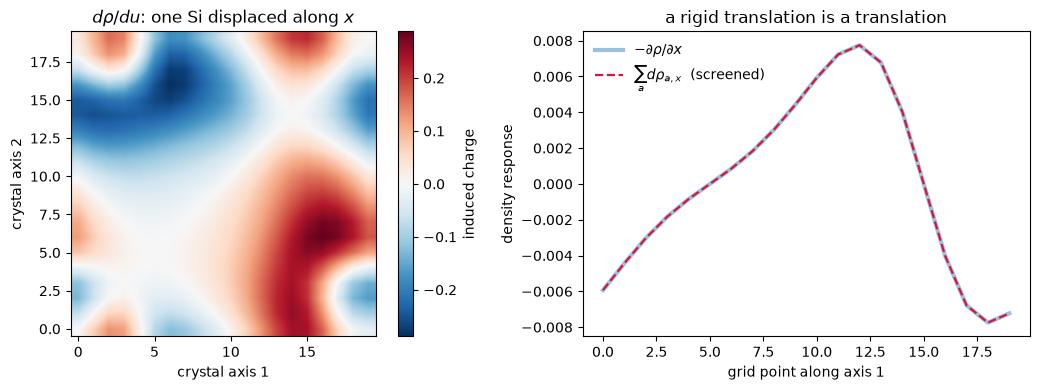

In [3]:
from defumat.basis.fft import g_to_r, r_to_g   # no facade route to rho(G)

grid = silicon.calculation.basis.dense
cartesian = grid.cartesian(silicon.system.cell)
rho_g = r_to_g(np.asarray(silicon.scf_result.density)[0], grid.fft_index)
exact = -np.real(g_to_r(1j * cartesian[:, 0] * rho_g, grid.fft_index, grid.grid))
translated = phonons.induced_density[:, 0, 0].sum(axis=0)

fig, (left, right) = plt.subplots(1, 2, figsize=(11.0, 4.0))
plane = phonons.induced_density[0, 0, 0].sum(axis=2)
limit = np.abs(plane).max()
image = left.imshow(plane.T, origin="lower", cmap="RdBu_r", vmin=-limit, vmax=limit,
                    interpolation="bilinear")
left.set(title=r"$d\rho/du$: one Si displaced along $x$", xlabel="crystal axis 1",
         ylabel="crystal axis 2")
fig.colorbar(image, ax=left, label="induced charge")

line, axis = np.s_[:, 5, 5], np.arange(exact.shape[0])
right.plot(axis, exact[line], lw=3, alpha=0.45, label=r"$-\partial\rho/\partial x$")
right.plot(axis, translated[line], "--", lw=1.6, color="crimson",
           label=r"$\sum_a d\rho_{a,x}$  (screened)")
right.set(title="a rigid translation is a translation",
          xlabel="grid point along axis 1", ylabel="density response")
right.legend(frameon=False)
fig.tight_layout()

print("max relative difference over the whole grid   %.1e"
      % (np.abs(translated - exact).max() / np.abs(exact).max()))

They agree, and **only because the response is screened**: with the bare perturbation alone
the two curves differ by 52%.

`ph.x` is one of four checks and the other three come from inside the calculation itself.
The one that matters most is a finite difference of *forces* -- displace, re-converge,
difference -- because a difference at frozen density would give back only the first of the
two terms, and only a re-converged run has let the electrons follow. It agrees to 2.1e-5
Ry/bohr² on force constants of order 0.28, and is quoted rather than run here, at two extra
self-consistent runs per column.

## The acoustic modes, which are a diagnostic and not an answer

Translating a whole crystal costs no energy, so three frequencies are zero *exactly*. What
comes out instead -- 4 cm⁻¹ here, 2 from `ph.x` -- is the plane-wave basis's own error: the
basis does not follow the atoms, so the energy depends slightly on where they sit relative to
it. Both are $10^{-4}$ of the force constants, and neither is physics. Neither code imposes
the sum rule by default, because the residue is the cheapest diagnostic there is and hiding
it would hide a real error just as effectively.

## A metal, where the occupations respond too

Everything above is an insulator, whose occupied manifold is sharply separated from the empty
one. In a metal it is not: displacing an atom moves states across the Fermi level, so the
occupations themselves respond and the response is weighted by how partially filled each
state is. This is two-atom aluminium -- fcc with its cell doubled, so three of the six modes
are acoustic and three are folded in from the zone boundary.

In [4]:
print("silicon, sum rule imposed:  %s"
      % np.array2string(silicon.get_phonons(acoustic_sum_rule=True).frequencies,
                        precision=3))

metal = Calculator.from_file(CASES / "al2-metal.in", pseudo_dir=PSEUDO,
                             announce=False).get_phonons()
PH_X = np.array([1.108857, 1.827469, 1.924700, 146.710511, 146.714378, 311.035401])
print("\naluminium [cm^-1]      here        ph.x")
for here, there in zip(metal.frequencies, PH_X):
    print("                 %10.4f  %10.4f" % (here, there))
print("\nacoustic sum rule  %.2e Ry/bohr^2,  against on-site force constants of %.4f"
      % (np.abs(metal.matrix.sum(axis=2)).max(),
         np.abs(metal.matrix[0, :, 0, :]).max()))

silicon, sum rule imposed:  [1.494e-06 9.624e-06 1.014e-05 5.101e+02 5.101e+02 5.101e+02]



aluminium [cm^-1]      here        ph.x
                     0.6997      1.1089
                     1.6067      1.8275
                     1.7247      1.9247
                   146.7093    146.7105
                   146.7132    146.7144
                   311.0335    311.0354

acoustic sum rule  1.06e-05 Ry/bohr^2,  against on-site force constants of 0.0476


## Away from the zone centre

A phonon is a wave, and so far every frequency in this notebook has been the wave of
infinite wavelength: all the cells move together. A phonon at wavevector $\mathbf q$ moves
them out of step,

$$ \mathbf u_s(\mathbf R) = \mathbf u_s \, e^{i \mathbf q \cdot \mathbf R} $$

and that is a pattern the unit cell does not have. It repeats only after however many cells
it takes for $e^{i \mathbf q \cdot \mathbf R}$ to come back to one, which for a general
$\mathbf q$ is never. Displacing the atoms and measuring the energy therefore means building
a supercell, and the cost of a phonon dispersion by that route is the cost of a supercell per
wavevector.

Linear response escapes it, and the reason is worth one line. The *change* in every quantity
is $e^{i \mathbf q \cdot \mathbf r}$ times something that is still periodic in the original
cell. So the perturbed orbital is again a Bloch state, at $\mathbf k + \mathbf q$ instead of
$\mathbf k$, and the whole calculation stays in the two-atom cell. What a wavevector costs is
one more set of plane waves, not one more crystal.

$$ D_{I\alpha,J\beta}(\mathbf q)
   = \sum_{\mathbf R} \frac{\partial^2 E}{\partial u_{I\alpha}(0)\,\partial u_{J\beta}(\mathbf R)}
     \, e^{i \mathbf q \cdot \mathbf R}, \qquad
   \omega^2(\mathbf q)\,\mathbf e = \frac{D(\mathbf q)}{\sqrt{M_I M_J}}\,\mathbf e $$

$D(\mathbf q)$ is hermitian rather than symmetric, and its eigenvalues are the branches of
the dispersion. Silicon has six: two atoms in the cell, three directions each, splitting into
three acoustic branches that vanish at $\Gamma$ and three optical ones that do not.

In [5]:
silicon_q = Calculator.from_file(CASES / "si-epsilon-unshifted-nosym.in",
                                pseudo_dir=PSEUDO, announce=False)

POINTS = {"$\\Gamma$": (0.0, 0.0, 0.0), "$L$": (0.5, -0.5, 0.5), "$X$": (0.0, -1.0, 0.0)}
PH_X = {"$\\Gamma$": [3.2736] * 3 + [519.1982] * 3,
        "$L$": [101.8428, 101.8428, 382.2406, 405.1208, 488.0194, 488.0194],
        "$X$": [132.8053, 132.8053, 405.3589, 405.3589, 455.1387, 455.1387]}

branches = {label: silicon_q.get_phonons_at_q(q=q, q_cartesian=True).frequencies
            for label, q in POINTS.items()}
for label in POINTS:
    print("%-9s %s" % (label, np.array2string(branches[label], precision=2)))
    print("   ph.x  %s" % np.array2string(np.array(PH_X[label]), precision=2))

$\Gamma$  [  4.32   4.32   4.32 519.21 519.21 519.21]
   ph.x  [  3.27   3.27   3.27 519.2  519.2  519.2 ]
$L$       [101.79 101.79 382.24 405.1  488.03 488.03]
   ph.x  [101.84 101.84 382.24 405.12 488.02 488.02]
$X$       [132.8  132.8  405.32 405.32 455.12 455.12]
   ph.x  [132.81 132.81 405.36 405.36 455.14 455.14]


The three acoustic branches collapse at $\Gamma$ because translating the whole crystal costs
no energy, and what is printed there instead is the small residue of the plane-wave basis.
Everywhere else the six branches are real frequencies, and they are what a neutron scattering
experiment measures. Silicon's transverse acoustic branch is famously flat, which is why
$L$ and $X$ put it at 102 and 133 cm⁻¹ while the optical branch has barely moved from its
zone-centre 519.

The comparison against `ph.x` is worth one sentence, because the two calculations do not
sample the zone the same way: Quantum ESPRESSO reduces the eight symmetry-inequivalent
$k$-points and averages the response back over the symmetry group, while this runs all
sixty-four and averages nothing. Agreeing to **0.05 cm⁻¹** on twelve zone-boundary
frequencies is therefore a statement about both routes.

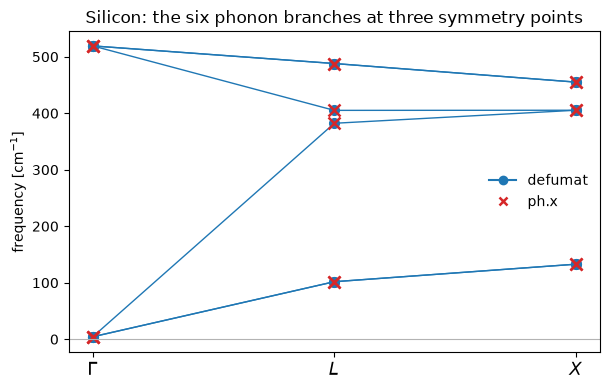

In [6]:
fig, ax = plt.subplots(figsize=(6.2, 4.0))
place = {"$\\Gamma$": 0, "$L$": 1, "$X$": 2}
here = np.array([branches[label] for label in place])
there = np.array([PH_X[label] for label in place])

ax.plot(list(place.values()), here, "-o", color="#1f77b4", markersize=7, linewidth=1)
ax.plot(list(place.values()), there, "x", color="#d62728", markersize=8, mew=1.8)
ax.plot([], [], "-o", color="#1f77b4", label="defumat")
ax.plot([], [], "x", color="#d62728", label="ph.x", mew=1.8)
ax.set_xticks(list(place.values()), list(place.keys()), fontsize=13)
ax.set_ylabel("frequency [cm$^{-1}$]")
ax.set_title("Silicon: the six phonon branches at three symmetry points")
ax.axhline(0.0, color="0.7", linewidth=0.8)
ax.legend(loc="center right", frameon=False)
fig.tight_layout()

The lines joining the points are a guide to the eye and not a dispersion: the branches between
these wavevectors are separate calculations, one per $\mathbf q$. Getting a smooth curve out
of a handful of them is a second step, in which the force constants are transformed back to
real space, where they are short ranged, and interpolated. That step is not here yet, and
neither is the saving that comes with it: the symmetry that relates one wavevector to another
is a different group from the crystal's, so this runs the full $k$-grid where Quantum
ESPRESSO runs a wedge.

What is here works for norm-conserving pseudopotentials in an insulator. Ultrasoft and PAW
datasets are refused at $\mathbf q \neq 0$, and so are metals, magnetism and spin-orbit
coupling.

The three real modes land within **0.002 cm⁻¹** of `ph.x`, tighter than silicon's 0.05, and
the folded pair splits by the same 0.004 `ph.x` splits it by. That near-degeneracy is the
sharper statement: this cell is run `nosym`, so nothing symmetrises the assembled matrix and
the splitting has to come out of the calculation rather than be imposed on it.

**The acoustic sum rule is the number to watch in a metal.** A response that counts the
occupations wrongly still converges, still returns a symmetric matrix, and puts the optical
modes at 198 and 309 cm⁻¹ with the missing weight parked in the acoustic ones at 156.
Nothing but the sum rule and the reference says so.

The occupations' own first-order change looks like a separate term and is not: the
$(f_i - f_j)/(\varepsilon_i - \varepsilon_j)$ structure of the smeared projector already *is*
that term, and it vanishes identically for an insulator, where every occupied $f$ is 1.

## Ultrasoft, PAW, and what is refused

With an ultrasoft dataset the overlap operator **moves with the atoms**, since the
augmentation charge and the projectors travel with their own nucleus. That changes the
constraint the states are subject to, and so changes what a second derivative of the energy
means. Everything the two datasets add vanishes identically when the overlap is the identity,
which is what keeps the norm-conserving number in the header table unchanged to round-off.

What is refused is one *combination* rather than a dataset: an ultrasoft or PAW **metal**,
where the moving overlap and the responding occupations meet.

---
The tests behind this notebook: `tests/regression/test_phonons.py` and
`tests/regression/test_phonons_at_q.py`, which hold the
frequencies against `ph.x` on all three kinds of dataset and on the metal, the rigid
translation reproducing $-\partial\rho/\partial x$, whole columns of the matrix against
finite-differenced forces, and the symmetry-reduced wedge against the whole closed grid.